In [1]:
from pathlib import Path
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
path = Path.cwd()
data_path = path / "Data" / "mental_heath_unbanlanced.csv"
df = pd.read_csv(data_path)
df.head()

,Unique_ID,text,status
0,0.0,oh my gosh,Anxiety
1,1.0,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2.0,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3.0,I've shifted my focus to something else but I'...,Anxiety
4,4.0,"I'm restless and restless, it's been a month n...",Anxiety


## Data Exploration

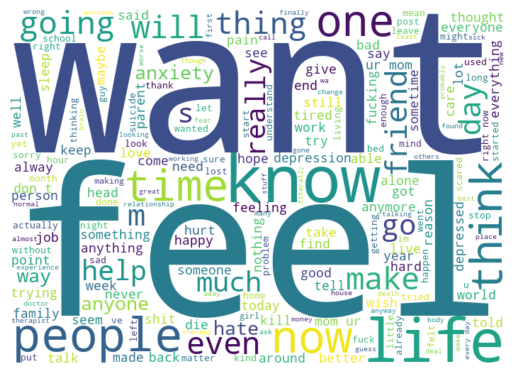

In [3]:
# Wordcloud
text = df['text'].str.cat() # Make the text into one large paragraph
wordcloud = WordCloud(width = 700, height = 500, background_color = 'white').generate(text) # Has built in filter for stop words

# Plot
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mehre\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

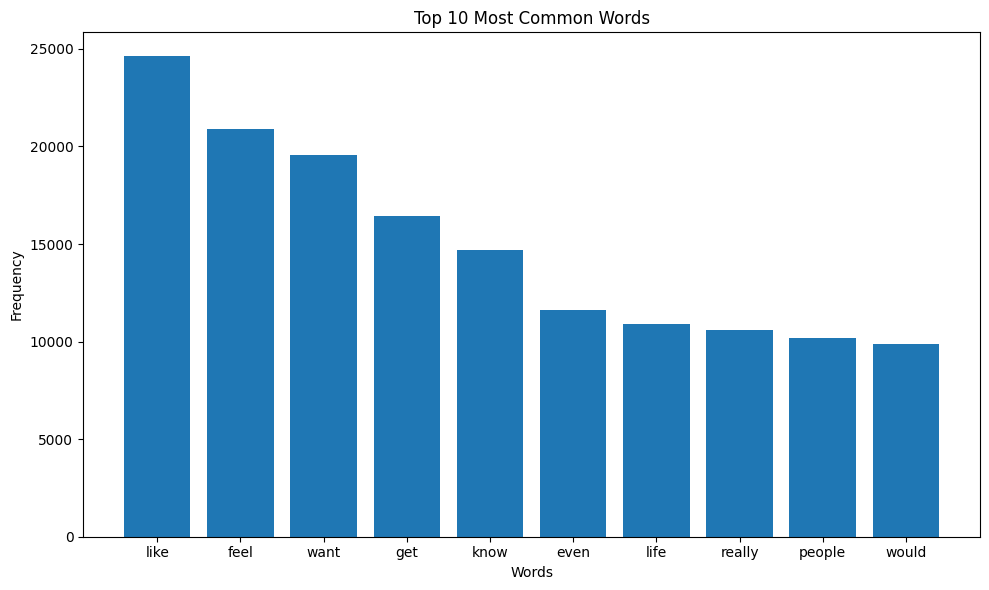

In [7]:
from collections import Counter
from nltk.corpus import stopwords

# Getting most frequent words
def plot_most_freq_words(text, stopwords):
    """
    Function that takes in raw text, cleans it and plots the most frequent words
    """
    
    # Preprocessing text
    text = text.lower()
    words = text.split()
    
    clean_words = []
    for word in words:
        if word not in stopwords:
            clean_words.append(word)

    # Count word frequencies
    word_counts = Counter(clean_words)    
    top_10_words = word_counts.most_common(10)
    word_labels_10 = [word for word, _ in top_10_words]
    word_counts_10 = [count for _, count in top_10_words]
    
    # Plot
    plt.figure(figsize = (10, 6))
    plt.bar(word_labels_10, word_counts_10)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.title('Top 10 Most Common Words')
    plt.tight_layout()
    plt.show()
    
    # Return counts for all words
    return pd.DataFrame(word_counts.items(), columns = ['Word', 'Count'])

stop_words = set(stopwords.words('english'))    
freq_df = plot_most_freq_words(text, stop_words)